In [3]:
# Carga de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from nltk.corpus import stopwords
import nltk

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
# Lectura del dataset
df = pd.read_csv(
    "Reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

df = df[['Score','Text']]

df = df.dropna()

# el dataset tiene 1000 datos, lo recortamos a unos 500
df = df.sample(
    n=500,
    random_state=42
)

df.reset_index(
    drop=True,
    inplace=True
)

df.head()

,Score,Text
0,5,My husband and I LOVE these chips! Personally ...
1,5,I love the aroma and the taste of the fruit an...
2,5,we have fed our cats a lot of stuff. These 2 b...
3,5,This tri-color couscous is really good...full ...
4,1,I recently purchased this on sale at my local ...


In [6]:
print(df.shape)

df.info()

(500, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Score   500 non-null    int64 
 1   Text    500 non-null    object
dtypes: int64(1), object(1)
memory usage: 7.9+ KB


In [7]:
df['Score'].value_counts().sort_index()

,count
Score,
1,44
2,25
3,44
4,60
5,327


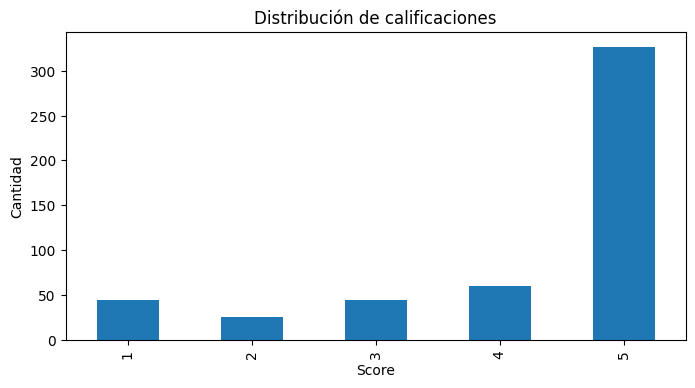

In [8]:
# Distribución de calificaciones según el score
plt.figure(figsize=(8,4))

df['Score'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title(
    'Distribución de calificaciones'
)

plt.xlabel(
    'Score'
)

plt.ylabel(
    'Cantidad'
)

plt.show()

In [11]:
## Construcción de clases de sentimiento

'''Las reseñas se transforman en dos clases:

- Negativo: Score 1 o 2
- Positivo: Score 4 o 5

Las reseñas neutrales (Score = 3) son eliminadas.'''
def sentimiento(score):

    if score <= 2:
        return 'Negativo'

    elif score >= 4:
        return 'Positivo'

    else:
        return 'Neutral'

df['Sentimiento'] = df[
    'Score'
].apply(sentimiento)

df = df[
    df['Sentimiento'] != 'Neutral'
]

df.shape

df = df[
    df['Sentimiento'] != 'Neutral'
]

df.shape

(456, 3)

In [12]:
# Preprocesamiento de texto y limpieza
stop_words = set(
    stopwords.words('english')
)

def limpiar_texto(texto):

    texto = str(texto).lower()

    texto = re.sub(
        r'\d+',
        '',
        texto
    )

    texto = re.sub(
        r'[^\w\s]',
        ' ',
        texto
    )

    palabras = texto.split()

    palabras = [
        p for p in palabras
        if p not in stop_words
    ]

    return " ".join(palabras)


In [13]:
df['Text_clean'] = df[
    'Text'
].apply(
    limpiar_texto
)

In [14]:
df[
    ['Text','Text_clean']
].head()

,Text,Text_clean
0,My husband and I LOVE these chips! Personally ...,husband love chips personally think flavor per...
1,I love the aroma and the taste of the fruit an...,love aroma taste fruit vanilla combo addition ...
2,we have fed our cats a lot of stuff. These 2 b...,fed cats lot stuff boy cats picky eaters loved...
3,This tri-color couscous is really good...full ...,tri color couscous really good full flavor fun...
4,I recently purchased this on sale at my local ...,recently purchased sale local grocery store kn...


In [15]:
# División del entrenamiento-prueba
X_train, X_test, y_train, y_test = train_test_split(

    df['Text_clean'],

    df['Sentimiento'],

    test_size=0.30,

    random_state=42,

    stratify=df['Sentimiento']

)

In [16]:
print(X_train.shape)
print(X_test.shape)

(319,)
(137,)


In [17]:
## Diseño de experimentos
'''
Se evaluarán:

- CountVectorizer
- TF-IDF

con:

- Naive Bayes
- Logistic Regression
- SVM

y distintos hiperparámetros.
'''

resultados = []

In [18]:
# Count + Naive Bayes
for alpha in [0.1,0.5,1]:

    modelo = Pipeline([

        ('vect',
         CountVectorizer()),

        ('clf',
         MultinomialNB(
             alpha=alpha
         ))

    ])

    modelo.fit(
        X_train,
        y_train
    )

    pred = modelo.predict(
        X_test
    )

    resultados.append([

        'Count',

        'Naive Bayes',

        alpha,

        accuracy_score(
            y_test,
            pred
        )

    ])

In [19]:
# Count + Logistic
for c in [0.1,1,10]:

    modelo = Pipeline([

        ('vect',
         CountVectorizer()),

        ('clf',
         LogisticRegression(
             C=c,
             max_iter=1000
         ))

    ])

    modelo.fit(
        X_train,
        y_train
    )

    pred = modelo.predict(
        X_test
    )

    resultados.append([

        'Count',

        'Logistic Regression',

        c,

        accuracy_score(
            y_test,
            pred
        )

    ])

In [20]:
# Count + SVM
for c in [0.1,1,10]:

    modelo = Pipeline([

        ('vect',
         CountVectorizer()),

        ('clf',
         LinearSVC(C=c))

    ])

    modelo.fit(
        X_train,
        y_train
    )

    pred = modelo.predict(
        X_test
    )

    resultados.append([

        'Count',

        'SVM',

        c,

        accuracy_score(
            y_test,
            pred
        )

    ])

In [21]:
# TF-IDF + Naive Bayes
for alpha in [0.1,0.5,1]:

    modelo = Pipeline([

        ('vect',
         TfidfVectorizer()),

        ('clf',
         MultinomialNB(
             alpha=alpha
         ))

    ])

    modelo.fit(
        X_train,
        y_train
    )

    pred = modelo.predict(
        X_test
    )

    resultados.append([

        'TF-IDF',

        'Naive Bayes',

        alpha,

        accuracy_score(
            y_test,
            pred
        )

    ])

In [23]:
# TF-IDF + Logistic
for alpha in [0.1,0.5,1]:

    modelo = Pipeline([

        ('vect',
         TfidfVectorizer()),

        ('clf',
         MultinomialNB(
             alpha=alpha
         ))

    ])

    modelo.fit(
        X_train,
        y_train
    )

    pred = modelo.predict(
        X_test
    )

    resultados.append([

        'TF-IDF',

        'Naive Bayes',

        alpha,

        accuracy_score(
            y_test,
            pred
        )

    ])

In [24]:
# TF-IDF + SVM
for c in [0.1,1,10]:

    modelo = Pipeline([

        ('vect',
         TfidfVectorizer()),

        ('clf',
         LinearSVC(C=c))

    ])

    modelo.fit(
        X_train,
        y_train
    )

    pred = modelo.predict(
        X_test
    )

    resultados.append([

        'TF-IDF',

        'SVM',

        c,

        accuracy_score(
            y_test,
            pred
        )

    ])

In [25]:
# Resultados
resultados = pd.DataFrame(

    resultados,

    columns=[
        'Vectorizador',
        'Modelo',
        'Parametro',
        'Accuracy'
    ]

)

resultados.sort_values(
    'Accuracy',
    ascending=False
)

,Vectorizador,Modelo,Parametro,Accuracy
17,TF-IDF,SVM,10.0,0.846715
2,Count,Naive Bayes,1.0,0.846715
14,TF-IDF,Naive Bayes,1.0,0.846715
13,TF-IDF,Naive Bayes,0.5,0.846715
15,TF-IDF,SVM,0.1,0.846715
16,TF-IDF,SVM,1.0,0.846715
11,TF-IDF,Naive Bayes,1.0,0.846715
10,TF-IDF,Naive Bayes,0.5,0.846715
6,Count,SVM,0.1,0.839416
1,Count,Naive Bayes,0.5,0.839416


In [26]:
# Mejor modelo
resultados.sort_values(
    'Accuracy',
    ascending=False
).head(1)

,Vectorizador,Modelo,Parametro,Accuracy
17,TF-IDF,SVM,10.0,0.846715


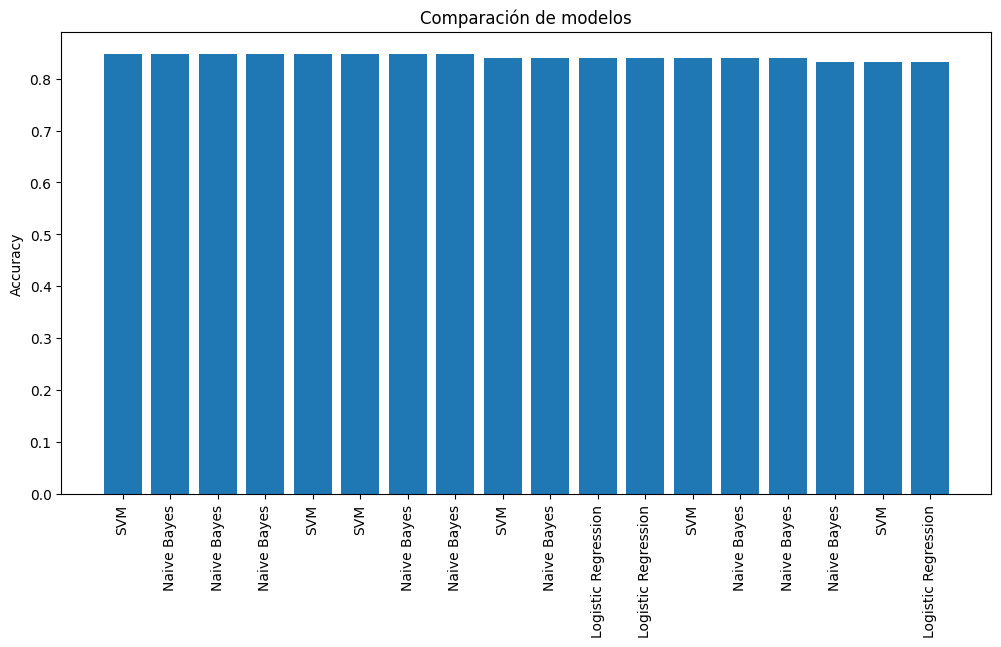

In [27]:
# Gráficas
top = resultados.sort_values(
    'Accuracy',
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top)),
    top['Accuracy']
)

plt.xticks(
    range(len(top)),
    top['Modelo'],
    rotation=90
)

plt.title(
    'Comparación de modelos'
)

plt.ylabel(
    'Accuracy'
)

plt.show()